In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
# Load dataset
df = pd.read_csv("netflix_titles.csv")

# Show first 5 rows
df.head()

,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,listed_in,description
0,s1,Movie,Dick Johnson Is Dead,Kirsten Johnson,NaN,United States,"September 25, 2021",2020,PG-13,90 min,Documentaries,"As her father nears the end of his life, filmm..."
1,s2,TV Show,Blood & Water,NaN,"Ama Qamata, Khosi Ngema, Gail Mabalane, Thaban...",South Africa,"September 24, 2021",2021,TV-MA,2 Seasons,"International TV Shows, TV Dramas, TV Mysteries","After crossing paths at a party, a Cape Town t..."
2,s3,TV Show,Ganglands,Julien Leclercq,"Sami Bouajila, Tracy Gotoas, Samuel Jouy, Nabi...",NaN,"September 24, 2021",2021,TV-MA,1 Season,"Crime TV Shows, International TV Shows, TV Act...",To protect his family from a powerful drug lor...
3,s4,TV Show,Jailbirds New Orleans,NaN,NaN,NaN,"September 24, 2021",2021,TV-MA,1 Season,"Docuseries, Reality TV","Feuds, flirtations and toilet talk go down amo..."
4,s5,TV Show,Kota Factory,NaN,"Mayur More, Jitendra Kumar, Ranjan Raj, Alam K...",India,"September 24, 2021",2021,TV-MA,2 Seasons,"International TV Shows, Romantic TV Shows, TV ...",In a city of coaching centers known to train I...


In [3]:
# Dataset information
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8807 entries, 0 to 8806
Data columns (total 12 columns):
 #   Column        Non-Null Count  Dtype 
---  ------        --------------  ----- 
 0   show_id       8807 non-null   object
 1   type          8807 non-null   object
 2   title         8807 non-null   object
 3   director      6173 non-null   object
 4   cast          7982 non-null   object
 5   country       7976 non-null   object
 6   date_added    8797 non-null   object
 7   release_year  8807 non-null   int64 
 8   rating        8803 non-null   object
 9   duration      8804 non-null   object
 10  listed_in     8807 non-null   object
 11  description   8807 non-null   object
dtypes: int64(1), object(11)
memory usage: 825.8+ KB


In [4]:
# Check missing values
df.isnull().sum()

show_id            0
type               0
title              0
director        2634
cast             825
country          831
date_added        10
release_year       0
rating             4
duration           3
listed_in          0
description        0
dtype: int64

In [5]:
# Fill missing values

df['director'] = df['director'].fillna('Unknown')

df['cast'] = df['cast'].fillna('Unknown')

df['country'] = df['country'].fillna('Unknown')

df['rating'] = df['rating'].fillna(df['rating'].mode()[0])

df['date_added'] = df['date_added'].fillna('Not Available')

# Verify missing values
df.isnull().sum()

show_id         0
type            0
title           0
director        0
cast            0
country         0
date_added      0
release_year    0
rating          0
duration        3
listed_in       0
description     0
dtype: int64

In [6]:
# Statistical summary
df.describe(include='all')

,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,listed_in,description
count,8807,8807,8807,8807,8807,8807,8807,8807.000000,8807,8804,8807,8807
unique,8807,2,8807,4529,7693,749,1768,NaN,17,220,514,8775
top,s1,Movie,Dick Johnson Is Dead,Unknown,Unknown,United States,"January 1, 2020",NaN,TV-MA,1 Season,"Dramas, International Movies","Paranormal activity at a lush, abandoned prope..."
freq,1,6131,1,2634,825,2818,109,NaN,3211,1793,362,4
mean,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2014.180198,NaN,NaN,NaN,NaN
std,NaN,NaN,NaN,NaN,NaN,NaN,NaN,8.819312,NaN,NaN,NaN,NaN
min,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1925.000000,NaN,NaN,NaN,NaN
25%,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2013.000000,NaN,NaN,NaN,NaN
50%,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2017.000000,NaN,NaN,NaN,NaN
75%,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2019.000000,NaN,NaN,NaN,NaN


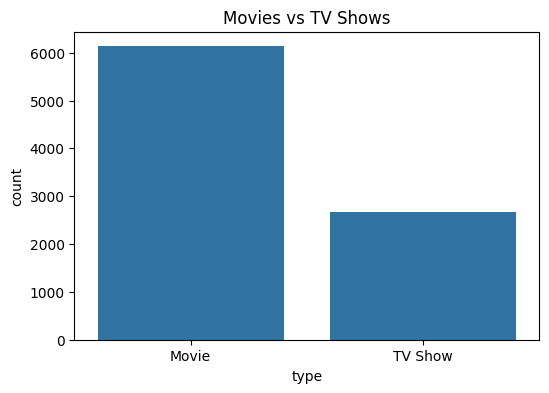

In [7]:
plt.figure(figsize=(6,4))

sns.countplot(x='type', data=df)

plt.title("Movies vs TV Shows")

plt.show()

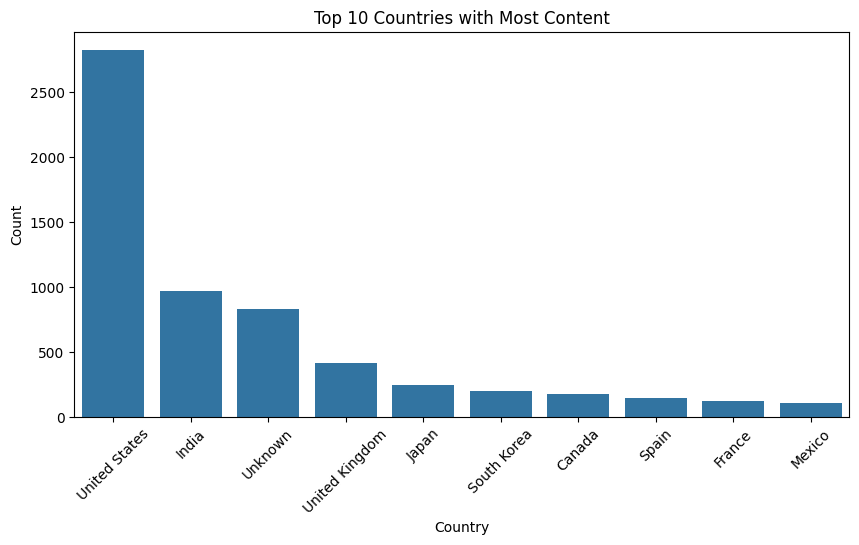

In [8]:
# Top countries
top_countries = df['country'].value_counts().head(10)

plt.figure(figsize=(10,5))

sns.barplot(x=top_countries.index, y=top_countries.values)

plt.xticks(rotation=45)

plt.title("Top 10 Countries with Most Content")

plt.xlabel("Country")
plt.ylabel("Count")

plt.show()

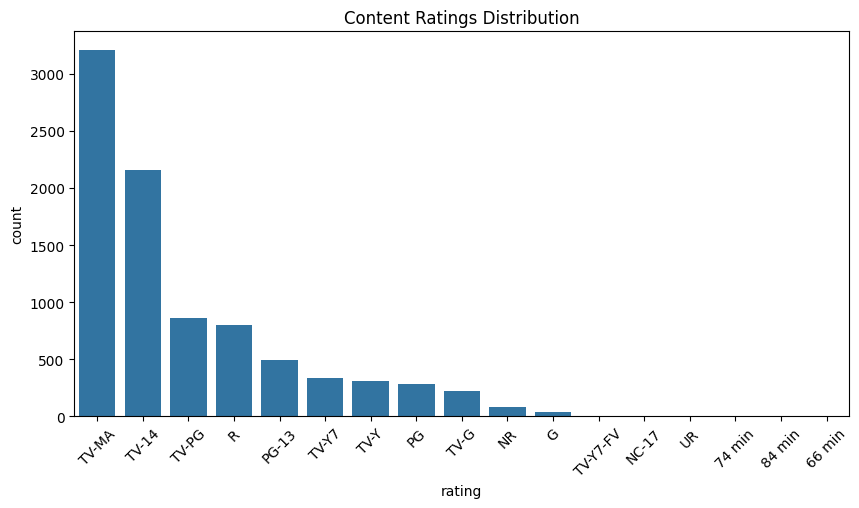

In [9]:
plt.figure(figsize=(10,5))

sns.countplot(x='rating', data=df,
              order=df['rating'].value_counts().index)

plt.xticks(rotation=45)

plt.title("Content Ratings Distribution")

plt.show()

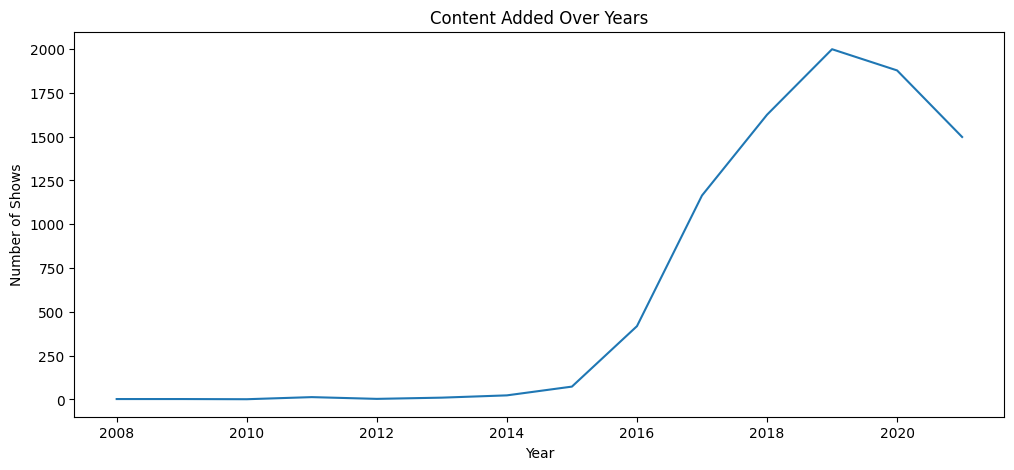

In [10]:
# Convert date_added to datetime
df['date_added'] = pd.to_datetime(df['date_added'],
                                  errors='coerce')

# Extract year
df['year_added'] = df['date_added'].dt.year

# Count content by year
year_counts = df['year_added'].value_counts().sort_index()

plt.figure(figsize=(12,5))

plt.plot(year_counts.index, year_counts.values)

plt.title("Content Added Over Years")

plt.xlabel("Year")
plt.ylabel("Number of Shows")

plt.show()

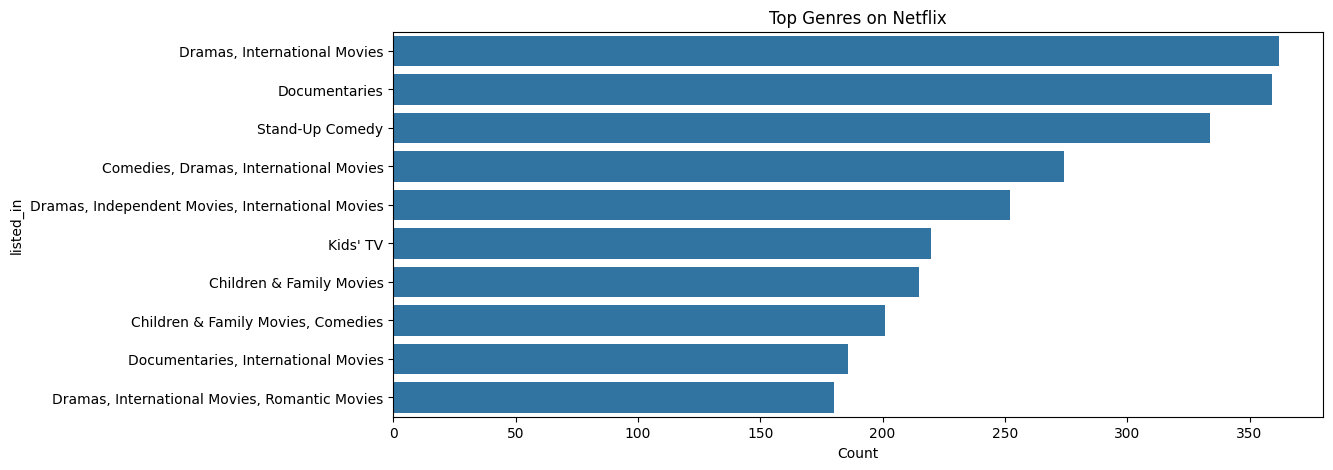

In [11]:
# Top genres
top_genres = df['listed_in'].value_counts().head(10)

plt.figure(figsize=(12,5))

sns.barplot(x=top_genres.values,
            y=top_genres.index)

plt.title("Top Genres on Netflix")

plt.xlabel("Count")

plt.show()

# Insights

- Netflix contains more Movies than TV Shows.
- The United States contributes the highest amount of content.
- TV-MA is one of the most common ratings.
- Netflix content increased rapidly after 2015.
- Drama and International Movies are among the most popular genres.

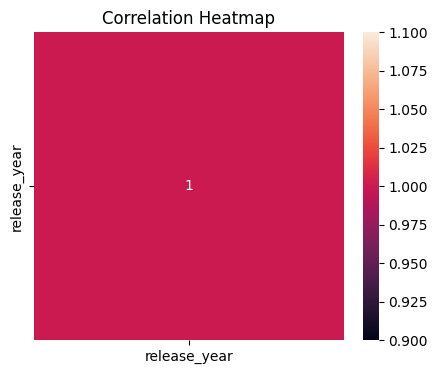

In [12]:
# Correlation analysis using release year

numeric_df = df[['release_year']]

correlation = numeric_df.corr()

plt.figure(figsize=(5,4))

sns.heatmap(correlation,
            annot=True)

plt.title("Correlation Heatmap")

plt.show()

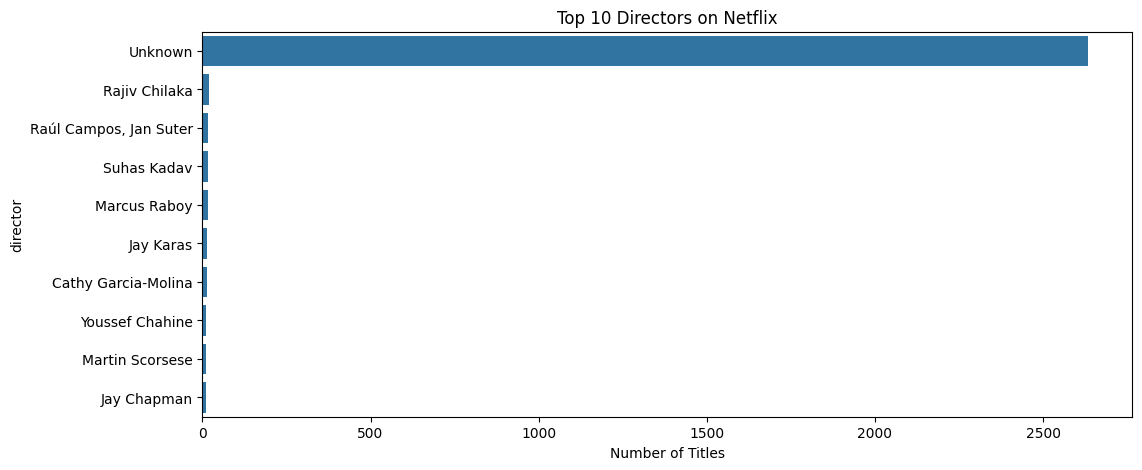

In [13]:
# Top directors
top_directors = df['director'].value_counts().head(10)

plt.figure(figsize=(12,5))

sns.barplot(x=top_directors.values,
            y=top_directors.index)

plt.title("Top 10 Directors on Netflix")

plt.xlabel("Number of Titles")

plt.show()

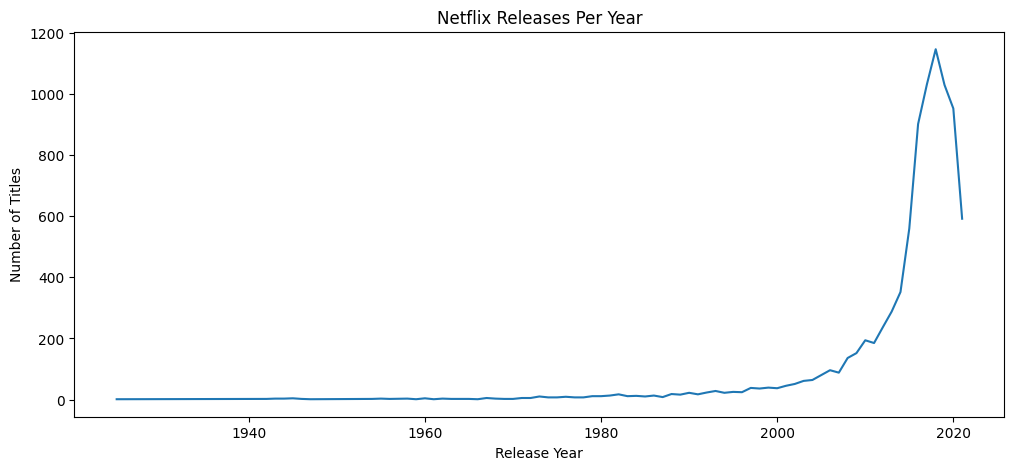

In [14]:
# Content release trend
release_counts = df['release_year'].value_counts().sort_index()

plt.figure(figsize=(12,5))

plt.plot(release_counts.index,
         release_counts.values)

plt.title("Netflix Releases Per Year")

plt.xlabel("Release Year")
plt.ylabel("Number of Titles")

plt.show()

# Final Report

## Objective
The objective of this project was to perform Exploratory Data Analysis (EDA) on the Netflix dataset to uncover patterns, trends, and insights.

## Key Findings

- Netflix has significantly more Movies than TV Shows.
- The United States produces the highest amount of Netflix content.
- TV-MA is among the most frequent content ratings.
- Content additions increased rapidly after 2015.
- Drama and International Movies dominate the platform.
- Certain directors contribute a large number of titles.

## Conclusion
The project successfully demonstrated data cleaning, statistical analysis, visualization, and trend discovery using Python data science libraries.